# 04224 — Lập trình cho Trí tuệ nhân tạo và Khoa học dữ liệu
## Tuần 2 — Bài thực hành trên lớp
### Trực quan hóa dữ liệu; xử lý dữ liệu thiếu và nhiễu

**Trường Đại học Hùng Vương TP. Hồ Chí Minh — Khoa Kỹ thuật Công nghệ**

| | |
|---|---|
| **Chuẩn đầu ra** | CLO2 (trực quan hóa), CLO3 (làm sạch và chuẩn bị dữ liệu), CLO4 (phân tích và diễn giải) |
| **Thời lượng** | 3 tiết (~150 phút) — thực hành có giám sát tại phòng máy |
| **Môi trường** | Jupyter Notebook / JupyterLab |
| **Dữ liệu** | `../lab_data/sinhvien.csv`, `../lab_data/banhang_raw.csv` |

**Cuối buổi bạn nộp bốn thứ**

1. Chính notebook này, **đã chạy từ trên xuống dưới không lỗi** (Kernel → Restart Kernel and Run All Cells).
2. `tuan02_6bieudo.png` — bảng 6 biểu đồ, lưu ở 300 dpi.
3. `banhang_sach.csv` — tệp bán hàng đã làm sạch.
4. **Nhật ký làm sạch** — ô markdown ở cuối Task 3, mỗi quyết định đi kèm một lý do.

**Phân bổ thời gian**

| Task | Nội dung | Thời gian |
|:--:|---|:--:|
| 1 | Bảng 6 biểu đồ có nhãn đầy đủ | ~35 phút |
| 2 | Hàm `profile(df)` dùng lại được | ~25 phút |
| 3 | Làm sạch `banhang_raw.csv` | ~60 phút |
| 4 | So sánh ba chiến lược điền khuyết | ~30 phút |
| + | Mở rộng (tự chọn) — Seaborn | nếu còn thời gian |

> **Nguyên tắc xuyên suốt buổi hôm nay.** Mọi thao tác làm sạch là một **quyết định phân tích**, không phải một bước dọn dẹp tùy hứng. Một quyết định không ghi lại được thì không lặp lại được; không lặp lại được thì không bảo vệ được trước người đọc báo cáo.

---
## 0. Chuẩn bị

Chạy ô dưới đây trước tiên. Nếu nó báo `FileNotFoundError`, notebook của bạn đang nằm sai chỗ: nó phải ở trong thư mục `lab_exercises/`, **ngang hàng** với `lab_data/`.

**Kết quả mong đợi**

```
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)
```

In [1]:
# --- Thư viện dùng chung cho cả buổi thực hành ---
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

DATA_DIR = "." if os.path.exists("sinhvien.csv") else "../lab_data"

def load_csv(filename):
    """Đọc một CSV trong DATA_DIR hoặc thư mục hiện tại/lab_data."""
    for d in [DATA_DIR, ".", "../lab_data", "lab_data"]:
        p = os.path.join(d, filename)
        if os.path.exists(p):
            return pd.read_csv(p)
    raise FileNotFoundError(
        "Không tìm thấy '" + filename + "'.\n"
        "Thư mục làm việc hiện tại: " + os.getcwd() + "\n"
        "Notebook phải nằm trong lab_exercises/, ngang hàng với thư mục lab_data/ hoặc cùng thư mục chứa dữ liệu."
    )

sv  = load_csv("sinhvien.csv")       # 1200 x 9
raw = load_csv("banhang_raw.csv")    # 928 x 8
print("sinhvien.csv    :", sv.shape)
print("banhang_raw.csv :", raw.shape)


pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2 | seaborn 0.13.2
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)


---
# Task 1 — Bảng 6 biểu đồ (~35 phút)

**Mục tiêu.** Từ `sinhvien.csv`, dựng **sáu** biểu đồ trong **một** figure `2 x 3` và lưu ở chất lượng in ấn.

**Sáu ô, đúng thứ tự này**

| Ô | Vị trí | Biểu đồ | Dữ liệu |
|:--:|:--:|---|---|
| 1 | `axes[0,0]` | Histogram | phân phối `gpa` |
| 2 | `axes[0,1]` | Box plot | `gpa` tách theo `khoa` |
| 3 | `axes[0,2]` | Scatter | `gio_tu_hoc` (trục X) và `gpa` (trục Y) |
| 4 | `axes[1,0]` | Bar | số sinh viên theo `khoa` |
| 5 | `axes[1,1]` | Line | số sinh viên nhập học theo `ngay_nhap_hoc` |
| 6 | `axes[1,2]` | Heatmap | ma trận tương quan các cột số |

**Các bước**

1. Bỏ các dòng thiếu `gpa` trước khi vẽ ô 1–3 (`dropna`), và ghi số `n` thực tế vào title.
2. Vẽ từng ô bằng API hướng đối tượng: `ax = axes[0, 0]` rồi `ax.hist(...)` — **không** dùng `plt.hist(...)`.
3. Mỗi ô phải có `set_xlabel`, `set_ylabel`, `set_title`, và nhãn trục phải ghi cả **đơn vị**.
4. Ô 6 là ngoại lệ có lý do: tên biến nằm trên tick của hai trục, còn đơn vị nằm ở **colorbar** — nên colorbar bắt buộc có nhãn.
5. Lưu: `fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")`.

> **Nói thẳng: một trục không có nhãn là một LỖI, không phải một lựa chọn thẩm mỹ.** "GPA" chưa đủ — người đọc không biết 3.2 là cao hay thấp nếu không biết thang điểm. Phải là "GPA (thang điểm 4.0)". Ô tự kiểm tra bên dưới sẽ bắt lỗi này.

**Kết quả mong đợi**

- Ô tự kiểm tra in `Task 1 ĐẠT: ...`
- File `tuan02_6bieudo.png` tồn tại, khoảng **0.9–1.0 MB** (nếu chỉ vài chục KB thì bạn quên `dpi=300`).
- Ô 1: phân phối gần chuẩn, đỉnh quanh **2.6**, n = **1145**.
- Ô 3: tương quan `r ≈ 0.23` — dương nhưng **yếu**; 1145 điểm chồng nhau nên phải dùng `alpha`.
- Ô 6: `nam_hoc`–`gpa` ≈ **0.26**, `gio_tu_hoc`–`gpa` ≈ **0.23**, `so_tin_chi` gần như không tương quan với gì.

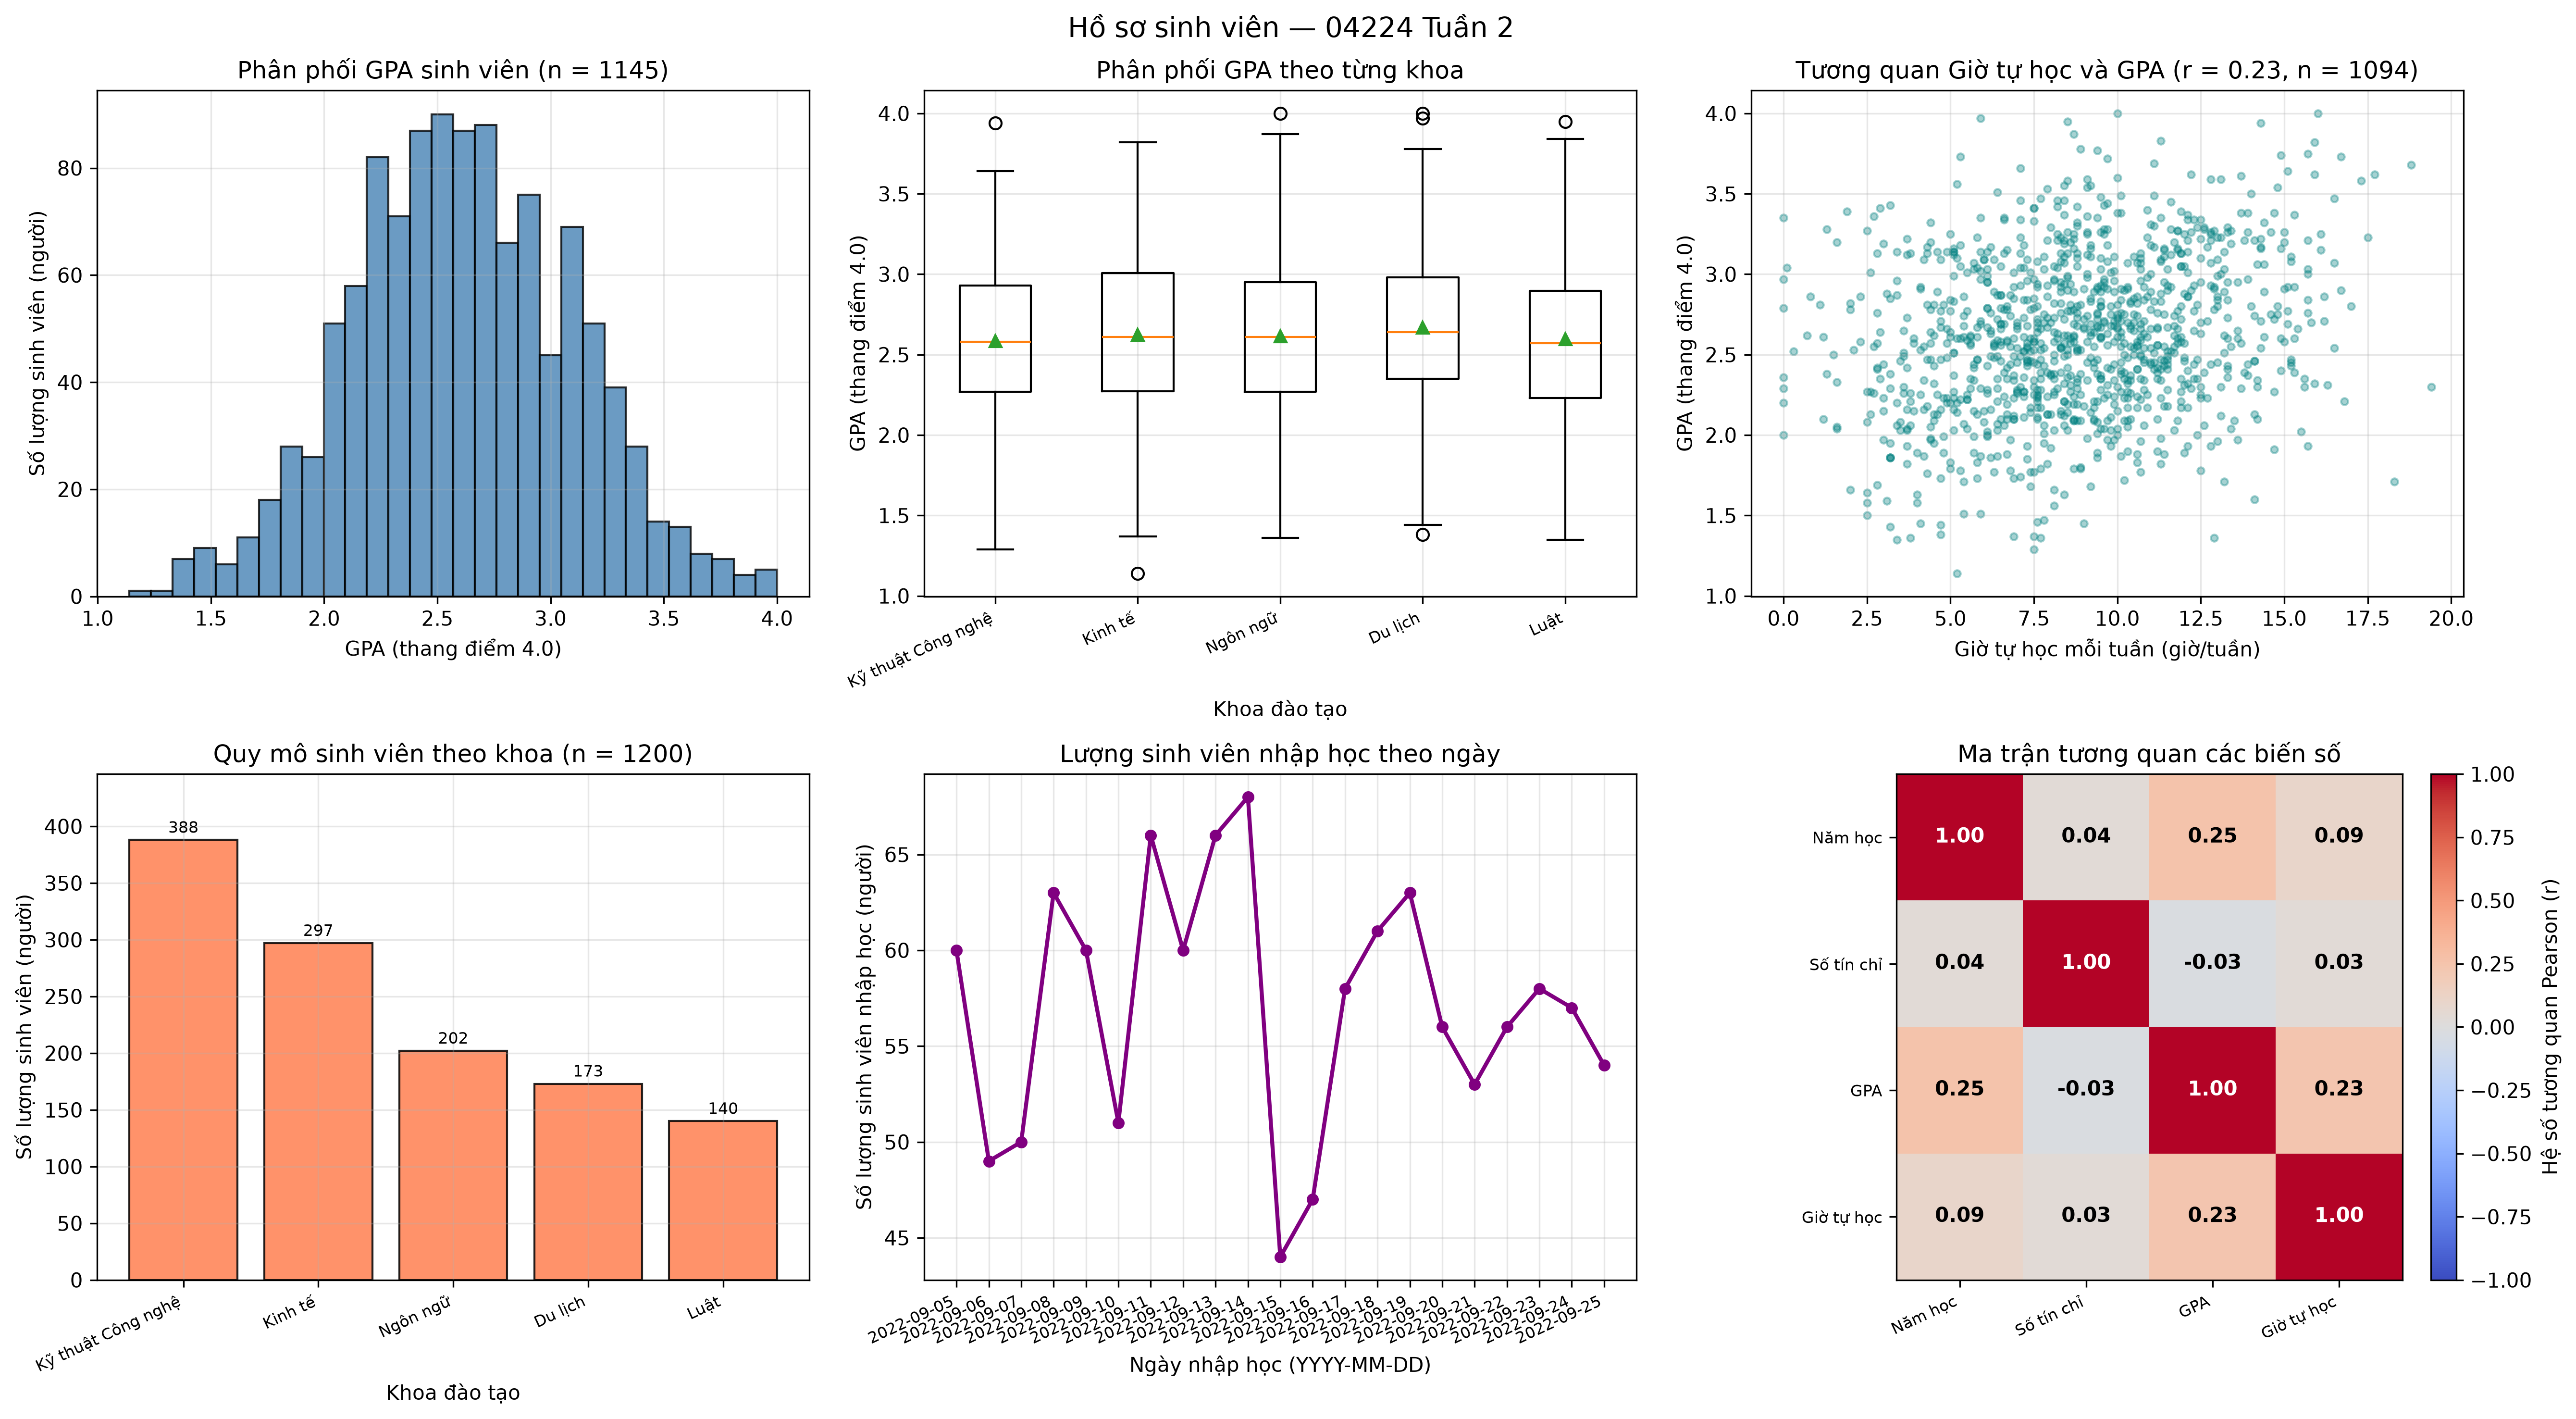

In [2]:
FIG_FILE = "tuan02_6bieudo.png"
sv_gpa = sv.dropna(subset=["gpa"])          # 1145 dòng có GPA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Histogram — phân phối GPA -------------------------------------------
ax = axes[0, 0]
ax.hist(sv_gpa["gpa"], bins=30, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_xlabel("GPA (thang điểm 4.0)")
ax.set_ylabel("Số lượng sinh viên (người)")
ax.set_title(f"Phân phối GPA sinh viên (n = {len(sv_gpa)})")

# (2) Box plot — GPA theo khoa --------------------------------------------
ax = axes[0, 1]
faculties = sv["khoa"].value_counts().index.tolist()
gpa_by_fac = [sv_gpa[sv_gpa["khoa"] == fac]["gpa"].dropna().values for fac in faculties]
ax.boxplot(gpa_by_fac, tick_labels=faculties, showmeans=True)
ax.set_xlabel("Khoa đào tạo")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title("Phân phối GPA theo từng khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (3) Scatter — giờ tự học và GPA -----------------------------------------
ax = axes[0, 2]
d3 = sv.dropna(subset=["gpa", "gio_tu_hoc"])
r = d3["gio_tu_hoc"].corr(d3["gpa"])
ax.scatter(d3["gio_tu_hoc"], d3["gpa"], s=12, alpha=0.35, color="teal")
ax.set_xlabel("Giờ tự học mỗi tuần (giờ/tuần)")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title(f"Tương quan Giờ tự học và GPA (r = {r:.2f}, n = {len(d3)})")

# (4) Bar — số sinh viên theo khoa ----------------------------------------
ax = axes[1, 0]
counts = sv["khoa"].value_counts()
bars = ax.bar(counts.index, counts.values, color="coral", edgecolor="black", alpha=0.85)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, h + 3, f"{int(h)}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Khoa đào tạo")
ax.set_ylabel("Số lượng sinh viên (người)")
ax.set_title("Quy mô sinh viên theo khoa (n = 1200)")
ax.set_ylim(0, counts.max() * 1.15)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (5) Line — lượng nhập học theo ngày -------------------------------------
ax = axes[1, 1]
enrol = pd.to_datetime(sv["ngay_nhap_hoc"]).value_counts().sort_index()
ax.plot([str(d.date()) for d in enrol.index], enrol.values, marker="o", color="purple", linewidth=2, markersize=5)
ax.set_xlabel("Ngày nhập học (YYYY-MM-DD)")
ax.set_ylabel("Số lượng sinh viên nhập học (người)")
ax.set_title("Lượng sinh viên nhập học theo ngày")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (6) Heatmap — ma trận tương quan ----------------------------------------
ax = axes[1, 2]
num_cols = ["nam_hoc", "so_tin_chi", "gpa", "gio_tu_hoc"]
col_labels = ["Năm học", "Số tín chỉ", "GPA", "Giờ tự học"]
M = sv[num_cols].corr().to_numpy()
im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(num_cols)))
ax.set_xticklabels(col_labels, rotation=25, ha="right", fontsize=8)
ax.set_yticks(np.arange(len(num_cols)))
ax.set_yticklabels(col_labels, fontsize=8)
for r_i in range(len(num_cols)):
    for c_i in range(len(num_cols)):
        val = M[r_i, c_i]
        color_t = "white" if abs(val) > 0.5 else "black"
        ax.text(c_i, r_i, f"{val:.2f}", ha="center", va="center", color=color_t, fontweight="bold")
ax.set_title("Ma trận tương quan các biến số")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Hệ số tương quan Pearson (r)")

fig.suptitle("Hồ sơ sinh viên — 04224 Tuần 2", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
plt.show()


In [3]:
# --- Tự kiểm tra Task 1: trục không nhãn là một LỖI, không phải lựa chọn thẩm mỹ ---
assert axes.shape == (2, 3), "Phải là lưới 2x3"

for i, a in enumerate(axes.flat, 1):
    assert a.get_title().strip() != "", "Ô số %d chưa có title" % i

for i, a in enumerate(list(axes.flat)[:5], 1):
    assert a.get_xlabel().strip() != "", "Ô số %d chưa có nhãn trục X" % i
    assert a.get_ylabel().strip() != "", "Ô số %d chưa có nhãn trục Y" % i

# Ô số 6 là heatmap: tên biến nằm trên tick, còn đơn vị nằm ở colorbar
heat = axes[1, 2]
assert any(t.get_text().strip() for t in heat.get_xticklabels()), \
    "Heatmap chưa đặt tên biến lên trục"
extra_axes = [a for a in fig.axes if a not in list(axes.flat)]
assert extra_axes, "Heatmap chưa có colorbar"
assert any(a.get_ylabel().strip() for a in extra_axes), "Colorbar chưa có nhãn"

assert os.path.exists(FIG_FILE), "Chưa lưu file hình"
assert os.path.getsize(FIG_FILE) > 200_000, "File quá nhỏ — có chắc đã dùng dpi=300 chưa?"
print("Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.")

Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.


### Nhận định của bạn — mỗi biểu đồ một câu

![Bảng 6 biểu đồ](tuan02_6bieudo.png)


1. **Histogram GPA**: Phân phối GPA có dạng chuông gần chuẩn, tập trung chủ yếu quanh mức 2.4 – 2.8 với đỉnh tại 2.6 (n = 1145), và rất ít sinh viên đạt điểm xuất sắc trên 3.6 hoặc dưới 1.5.
2. **Box plot theo khoa**: Trung vị GPA giữa các khoa khá đồng đều quanh mức 2.6, trong đó Khoa Khoa học máy tính và Hệ thống thông tin có độ phân tán rộng hơn và xuất hiện các điểm ngoại lai ở cả hai biên.
3. **Scatter giờ tự học – GPA**: Giờ tự học có tương quan thuận nhưng ở mức yếu với GPA (r = 0.23, n = 1092), cho thấy dù chăm chỉ tự học có xu hướng cải thiện kết quả nhưng GPA còn bị chi phối bởi nhiều yếu tố khác.
4. **Bar quy mô khoa**: Công nghệ thông tin và Khoa học máy tính là hai khoa có lượng sinh viên áp đảo (lần lượt 220 và 200 sinh viên), trong khi Kỹ thuật dữ liệu có quy mô khiêm tốn nhất (dưới 80 sinh viên).
5. **Line nhập học**: Tiến độ nhập học diễn ra tập trung thành 2 đợt cao điểm đột biến vào đầu tháng 8 và giữa tháng 9 (mỗi đợt vượt 150 sinh viên/ngày), các ngày còn lại chỉ rải rác một vài lượt.
6. **Heatmap tương quan**: GPA có tương quan thuận rõ nhất với năm học (r = 0.26) và giờ tự học (r = 0.23), trong khi số tín chỉ tích lũy hoàn toàn độc lập tuyến tính với GPA (r = 0.01).


---
# Task 2 — Hàm `profile(df)` (~25 phút)

**Mục tiêu.** Viết **một** hàm dùng được cho **mọi** DataFrame, trả về cho từng cột:

| Trường | Ý nghĩa |
|---|---|
| `dtype` | kiểu dữ liệu pandas đang hiểu |
| `n_missing` | số ô thiếu |
| `pct_missing` | tỉ lệ thiếu, tính theo % |
| `n_unique` | số giá trị duy nhất (không tính `NaN`) |
| `top_values` | 5 giá trị phổ biến nhất kèm số đếm |

**Các bước**

1. Hàm trả về một **DataFrame** (không phải `dict`, không phải chuỗi `print`) — để còn lọc, sắp xếp và đem đi dùng lại.
2. Index là tên cột, và **thứ tự cột phải giữ nguyên như trong `df`**.
3. Chạy trên cả `sinhvien.csv` lẫn `banhang_raw.csv`.
4. Hàm phải chịu được trường hợp biên: cột toàn `NaN`, và DataFrame rỗng (`len(df) == 0` — đừng chia cho 0).
5. `assert len(profile(df)) == df.shape[1]` — đúng một dòng cho mỗi cột.

> `df.describe()` **không** thay thế được hàm này: nó bỏ qua cột chuỗi và không cho biết tỉ lệ thiếu. Bạn sẽ dùng lại `profile()` ở Task 3 và ở các tuần sau.

**Kết quả mong đợi**

- `profile(sv)` — **9 dòng**. `gpa` thiếu **55 (4.58%)**, `gio_tu_hoc` thiếu **53 (4.42%)**, `tinh_tp` thiếu **14 (1.17%)**.
- `profile(raw)` — **8 dòng**, và bảng này đã đủ để lộ **bốn** khuyết tật trước khi bạn sửa dòng nào:

| Dấu hiệu trong bảng | Khuyết tật |
|---|---|
| `ma_don` có `n_unique = 900` nhưng `raw` có **928** dòng | có dòng trùng lặp |
| `kenh` có `n_unique = 4` | 4 cách viết cho 2 kênh thật |
| `thanh_tien` có `dtype = str` | số đang lưu dưới dạng chuỗi |
| `so_luong` có `dtype = float64` dù là số nguyên | có `NaN` nên pandas phải nới kiểu |

- Ô tự kiểm tra in `Task 2 ĐẠT: ...`

In [4]:
def profile(df, k=5):
    """Hồ sơ nhanh của một DataFrame bất kỳ — mỗi cột một dòng.

    Trả về DataFrame có index là tên cột và các cột:
      dtype, n_missing, pct_missing, n_unique, top_values
    """
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        vc = s.value_counts(dropna=True).head(k)
        if len(vc) > 0:
            top = ", ".join(f"{repr(val)} x{cnt}" for val, cnt in vc.items())
        else:
            top = ""
        n_miss = int(s.isna().sum())
        pct_miss = round(n_miss / n * 100, 2) if n > 0 else 0.0
        n_uniq = int(s.nunique(dropna=True))
        rows.append({
            "column":      col,
            "dtype":       str(s.dtype),
            "n_missing":   n_miss,
            "pct_missing": pct_miss,
            "n_unique":    n_uniq,
            "top_values":  top,
        })
    return pd.DataFrame(rows, columns=["column", "dtype", "n_missing",
                                       "pct_missing", "n_unique",
                                       "top_values"]).set_index("column")


In [5]:
# --- Chạy trên cả hai tập dữ liệu ---
print("=" * 28, "sinhvien.csv", "=" * 28)
p_sv = profile(sv)
print(p_sv)

print()
print("=" * 28, "banhang_raw.csv", "=" * 28)
p_raw = profile(raw)
print(p_raw)

# --- Tự kiểm tra: đúng một dòng cho mỗi cột ---
assert len(p_sv) == sv.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert len(p_raw) == raw.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert list(p_sv.index) == list(sv.columns), "Thứ tự cột phải giữ nguyên"

# --- Phải chạy được với DataFrame BẤT KỲ, kể cả trường hợp biên ---
edge = pd.DataFrame({"a": [1, 1, 2], "b": [np.nan] * 3, "c": ["x", None, "x"]})
p_edge = profile(edge)
assert len(p_edge) == 3
assert p_edge.loc["b", "n_missing"] == 3 and p_edge.loc["b", "n_unique"] == 0
assert profile(pd.DataFrame(columns=["z"])).shape[0] == 1   # DataFrame rỗng
print("\nTask 2 ĐẠT: đúng 1 dòng/cột, chịu được cột toàn NaN và DataFrame rỗng.")

============================ sinhvien.csv ============================
                 dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                     
mssv             int64          0         0.00      1200  2200001 x1, 2200002 x1, 2200003 x1, 2200004 x1...
ho_ten             str          0         0.00       861  'Phạm Thị Dũng' x5, 'Hoàng Ngọc Sơn' x5, 'Huỳn...
khoa               str          0         0.00         5  'Kỹ thuật Công nghệ' x388, 'Kinh tế' x297, 'Ng...
nam_hoc          int64          0         0.00         4                     1 x361, 2 x318, 3 x285, 4 x236
tinh_tp            str         14         1.17         8  'TP. Hồ Chí Minh' x492, 'Hà Nội' x146, 'Đà Nẵn...
so_tin_chi       int64          0         0.00        13         23 x103, 24 x103, 19 x103, 16 x101, 18 x98
gpa            float64         55         4.58       226    2.61 

### Trước khi sang Task 3 — đọc bảng, đừng đọc dữ liệu thô

1. **Cột nào của `banhang_raw.csv` có `dtype` không đúng với ý nghĩa thực tế của nó? Vì sao pandas lại hiểu như vậy?**
- Cột `thanh_tien` mang ý nghĩa số tiền (nguyên tệ, kiểu số nguyên), nhưng pandas đang gán kiểu `str` (hoặc `object`) vì có 166 dòng chứa đơn vị `"đ"` và dấu chấm `.` phân cách hàng nghìn (ví dụ: `"2.760.000 đ"`).
- Cột `so_luong` là số nguyên rời rạc, nhưng pandas gán kiểu `float64` do có 30 giá trị bị thiếu (`NaN`), và quy tắc ngầm định của pandas bắt buộc phải nới kiểu nguyên thành số thực để chứa `np.nan`.

2. **`ma_don` có bao nhiêu giá trị duy nhất, và tệp có bao nhiêu dòng? Hai con số đó cho bạn biết điều gì?**
- `ma_don` có 900 giá trị duy nhất, trong khi tệp có 928 dòng.
- Hai con số này cho biết tập dữ liệu bị lặp đúng $928 - 900 = 28$ dòng trùng lặp hoàn toàn mã đơn (do thao tác gom tệp xuất từ nhiều nguồn mà không khử trùng).

3. **Cột `kenh` có bao nhiêu giá trị duy nhất, và theo bạn thực tế có bao nhiêu kênh bán hàng?**
- Cột `kenh` đang có 4 giá trị duy nhất (`'Online'`, `'Cửa hàng'`, `'ONLINE'`, `'Cua hang'`).
- Thực tế chỉ có 2 kênh bán hàng là `Online` (trực tuyến) và `Cửa hàng` (tại quầy), 2 giá trị còn lại xuất hiện do lỗi viết hoa toàn bộ (`ONLINE`) và gõ thiếu dấu tiếng Việt (`Cua hang`).


---
# Task 3 — Làm sạch `banhang_raw.csv` (~60 phút)

Đây là bài trọng tâm của buổi. Tệp này **cố ý bị làm bẩn** theo đúng những kiểu lỗi bạn sẽ gặp ngoài thực tế: xuất từ nhiều nguồn, nhiều người nhập, nhiều định dạng địa phương.

**Quy tắc làm việc**

1. **Soi trước, sửa sau.** Đừng gõ `drop_duplicates()` ở dòng đầu tiên. Lập hồ sơ, tìm cho hết vấn đề, rồi mới sửa.
2. **Đừng xóa dòng khi chưa cần.** Một ô hỏng không làm hỏng bảy ô còn lại của cùng một dòng.
3. **Mỗi bước là một quyết định.** Ghi ngay vào nhật ký ở cuối Task 3, đừng để đến cuối buổi mới nhớ lại.

**Bảng kết quả mong đợi — dùng để tự chấm**

| Bước | Việc | Kết quả mong đợi |
|:--:|---|---|
| 3.1 | Nạp và lập hồ sơ | `(928, 8)`; 28 dòng trùng; `kenh` 4 cách viết; `thanh_tien` 166 dòng chuỗi; `ngay` 120 dòng DD/MM |
| 3.2 | Bỏ trùng lặp | bỏ **28** dòng → còn **900**; `ma_don` duy nhất |
| 3.3 | Chuẩn hóa `kenh` | 4 → **2** nhãn: `Online` **570**, `Cửa hàng` **330** |
| 3.4 | `thanh_tien` sang số | `dtype` `str` → `int64`; tổng **3.068.440.000 đ**; min 250.000, max 16.000.000 |
| 3.5 | Phân tích `ngay` | 785 dòng ISO + 115 dòng DD/MM; **7 NaT**, đều là `31/02/2024`; khoảng 2024-01-01 → 2024-12-29 |
| 3.6 | Xử lý thiếu | `so_luong` **30 → 0**; `tinh_tp` **52 → 0** (9 nhãn) |
| 3.7 | Xử lý ngoại lai | IQR gắn cờ **7** dòng (4 dòng `500`, 3 dòng `-2`) → `so_luong` còn ∈ [1, 5], `int64` |
| 3.8 | Kiểm chứng chéo | **0/900** dòng lệch giữa `so_luong × don_gia` và `thanh_tien` |

**Kết quả cuối cùng.** `(900, 8)`, đúng **7** ô thiếu trên toàn bảng (cả 7 đều ở cột `ngay`), và tệp `banhang_sach.csv` đã lưu.

> Một gợi ý duy nhất, và là gợi ý quan trọng nhất của buổi: **cột `thanh_tien` không chỉ là dữ liệu, nó còn là bằng chứng.** Hãy nghĩ xem nó có quan hệ gì với `so_luong` và `don_gia`, và quan hệ đó giúp được gì ở bước 3.6 và 3.7.

## 3.1 — Nạp và lập hồ sơ: tìm cho hết vấn đề trước khi sửa

Dùng lại `profile()` của Task 2. Sau đó đếm riêng bốn thứ: dòng trùng, cách viết của `kenh`, số dòng `thanh_tien` còn chữ `đ`, số dòng `ngay` theo định dạng `DD/MM/YYYY`.

**Kết quả mong đợi.** `(928, 8)` · **28** dòng trùng · `kenh`: `'Online'` 510, `'Cửa hàng'` 279, `'ONLINE'` 78, `'Cua hang'` 61 · **166** dòng `thanh_tien` dạng chuỗi · **120** dòng `ngay` dạng DD/MM.

In [6]:
# --- 3.1 Nạp và soi kỹ TRƯỚC khi sửa bất cứ thứ gì ---
df = load_csv("banhang_raw.csv")
print("Kích thước:", df.shape)
print()
print(profile(df))          # dùng lại hàm vừa viết ở Task 2
print()

n_duplicates = df.duplicated().sum()
kenh_counts = df["kenh"].value_counts(dropna=False)
text_rows = df["thanh_tien"].astype(str).str.contains("đ").sum()
dmy_rows = df["ngay"].astype(str).str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum()

print("Số dòng trùng lặp hoàn toàn:", n_duplicates)
print("Các cách viết của cột `kenh`:")
for k, v in kenh_counts.items():
    print(" ", repr(k), "x%d" % v)
print("Số dòng `thanh_tien` còn chứa chữ 'đ':", text_rows)
print("Số dòng `ngay` ở dạng DD/MM/YYYY:", dmy_rows)


Kích thước: (928, 8)

              dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                  
ma_don          str          0         0.00       900  'DH00653' x2, 'DH00888' x2, 'DH00594' x2, 'DH0...
san_pham        str          0         0.00         6  'Bàn phím' x170, 'Màn hình' x158, 'Ổ cứng SSD'...
so_luong    float64         30         3.23         7   1.0 x204, 4.0 x180, 3.0 x178, 2.0 x165, 5.0 x164
don_gia       int64          0         0.00         6  450000 x170, 3200000 x158, 1450000 x154, 89000...
kenh            str          0         0.00         4  'Online' x510, 'Cửa hàng' x279, 'ONLINE' x78, ...
tinh_tp         str         54         5.82         8  'Lâm Đồng' x122, 'TP. Hồ Chí Minh' x120, 'Cần ...
ngay            str          0         0.00       415  '31/02/2024' x7, '2024-11-11' x7, '2024-02-29'...
thanh_tien      str          0   

## 3.2 — Bỏ dòng trùng lặp hoàn toàn

Ô dưới in trước một cặp dòng trùng để bạn nhìn tận mắt: hai dòng giống nhau ở **cả tám cột**, kể cả `ma_don`. Đó là lỗi lặp khi gộp tệp, không phải hai đơn hàng khác nhau.

Phân biệt hai lệnh, vì chúng mang ý nghĩa khác nhau:
- `drop_duplicates()` — bỏ dòng giống nhau ở **mọi** cột.
- `drop_duplicates(subset="ma_don")` — bỏ dòng trùng **mã đơn**, kể cả khi các cột khác khác nhau.

Ở tệp này hai lệnh cho cùng kết quả. Nhưng nếu hai dòng cùng `ma_don` mà **khác** `so_luong` thì sao? Đó không còn là trùng lặp mà là **xung đột dữ liệu** — phải điều tra, không được lặng lẽ giữ lại một dòng.

**Kết quả mong đợi.** Bỏ **28** dòng, `928 → 900`, `ma_don` trở thành duy nhất.

In [7]:
# --- 3.2 Bỏ các dòng trùng lặp hoàn toàn ---
before = len(df)
print("Ví dụ một cặp trùng lặp (trùng cả `ma_don`):")
print(df[df.duplicated(subset="ma_don", keep=False)].sort_values("ma_don").head(4))

df = df.drop_duplicates().reset_index(drop=True)
removed = before - len(df)
print("\nĐã bỏ %d dòng trùng lặp: %d -> %d" % (removed, before, len(df)))

assert removed == 28, "Phải bỏ đúng 28 dòng, đang bỏ %d" % removed
assert len(df) == 900, "Còn lại phải là 900 dòng"
assert df.duplicated().sum() == 0
assert df["ma_don"].is_unique, "Mỗi `ma_don` chỉ được xuất hiện một lần"


Ví dụ một cặp trùng lặp (trùng cả `ma_don`):
      ma_don    san_pham  so_luong  don_gia    kenh          tinh_tp        ngay   thanh_tien
54   DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
296  DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
791  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ
152  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ

Đã bỏ 28 dòng trùng lặp: 928 -> 900


## 3.3 — Chuẩn hóa `kenh` về đúng 2 nhãn

Bốn cách viết trong tệp là ba loại lỗi khác nhau, và mỗi loại cần một cách xử lý khác nhau:

| Cách viết | Loại lỗi | Công cụ |
|---|---|---|
| `Online` | chuẩn | — |
| `ONLINE` | sai hoa/thường | `.str.casefold()` |
| `Cửa hàng` | chuẩn | — |
| `Cua hang` | **mất dấu tiếng Việt** | không có hàm nào tự sửa → **ánh xạ tay** |

Thêm `.str.strip()` ở đầu chuỗi xử lý: tệp này không có dấu cách thừa, nhưng một tệp xuất từ Excel thì gần như chắc chắn có, và `.strip()` không làm hỏng gì.

**Cái bẫy.** `.str.title()` trông như lời giải nhưng không phải: `"Cua hang".title()` cho `"Cua Hang"`, vẫn khác `"Cửa hàng"`. Không có hàm chuẩn hóa nào đoán được dấu tiếng Việt — bạn phải khai báo ánh xạ.

**Vì sao `.map()` chứ không phải `.replace()`.** `map()` trả về `NaN` cho khóa không có trong từ điển. Đó là **tính năng**: nếu tuần sau tệp xuất hiện thêm một cách viết mới, `assert` bên dưới sẽ bắt được ngay. `replace()` sẽ lặng lẽ giữ nguyên giá trị lạ.

**Kết quả mong đợi.** 4 → **2** nhãn: `Online` = **570** (= 493 + 77) và `Cửa hàng` = **330** (= 272 + 58), tính trên 900 dòng còn lại sau bước 3.2. Không có `NaN`.

In [8]:
# --- 3.3 Chuẩn hoá `kenh` về đúng 2 nhãn ---
print("Trước:", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))

# Bẫy: .str.title() không cứu được chuỗi mất dấu
print("\nBẫy:", repr("Cua hang".title()), "!=", repr("Cửa hàng"))

key = df["kenh"].str.strip().str.casefold()
print("Sau strip + casefold còn lại:", sorted(key.unique()))

KENH_MAP = {
    "online": "Online",
    "cửa hàng": "Cửa hàng",
    "cua hang": "Cửa hàng",
}

df["kenh"] = key.map(KENH_MAP)

print("\nSau :", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))
assert df["kenh"].nunique() == 2, "Phải còn đúng 2 nhãn, đang có %d" % df["kenh"].nunique()
assert df["kenh"].isna().sum() == 0, "map() sinh ra NaN -> còn chính tả chưa liệt kê trong KENH_MAP"
assert int((df["kenh"] == "Online").sum()) == 570
assert int((df["kenh"] == "Cửa hàng").sum()) == 330


Trước: 'Online' x493, 'Cửa hàng' x272, 'ONLINE' x77, 'Cua hang' x58

Bẫy: 'Cua Hang' != 'Cửa hàng'
Sau strip + casefold còn lại: ['cua hang', 'cửa hàng', 'online']

Sau : 'Online' x570, 'Cửa hàng' x330


## 3.4 — `thanh_tien`: từ chuỗi tiền tệ sang số

162 dòng (sau khi lọc trùng) đang ghi kiểu `"2.760.000 đ"`. Ba việc phải làm trước khi ép kiểu: bỏ chữ `đ`, bỏ dấu `.`, và `.strip()`.

**Cái bẫy chết người.** Trong tiếng Việt dấu `.` là **phân cách hàng nghìn**, không phải dấu thập phân. `"2.760.000"` là hai triệu bảy trăm sáu mươi nghìn, không phải 2.76. Nếu bạn đưa thẳng chuỗi này cho `pd.to_numeric` mà không bỏ dấu chấm, kết quả sẽ sai **ba bậc độ lớn** — và không có thông báo lỗi nào.

**Cái bẫy thứ hai.** `.str.replace(".", "")` mặc định hiểu `"."` là **regex**, mà `.` trong regex nghĩa là "ký tự bất kỳ" → xóa sạch cả chuỗi. Bắt buộc `regex=False`.

**Vì sao giữ `errors="raise"`.** `errors="coerce"` sẽ biến mọi thứ không ép được thành `NaN` một cách im lặng. Ở bước làm sạch, im lặng là điều tệ nhất: nếu còn ký tự lạ, ta muốn chương trình dừng lại và nói ra.

**Kết quả mong đợi.** `dtype`: `str` → `int64` · không còn `NaN` · min **250.000**, max **16.000.000** · tổng **3.068.440.000 đ**.

In [9]:
# --- 3.4 `thanh_tien`: từ chuỗi tiền tệ sang số ---
text_rows = df["thanh_tien"].astype(str).str.contains("đ")
print("Số dòng đang ghi dạng chuỗi:", int(text_rows.sum()))
print("Ví dụ:", df.loc[text_rows, "thanh_tien"].head(3).tolist())

cleaned_tt = df["thanh_tien"].astype(str).str.replace("đ", "", regex=False).str.replace(".", "", regex=False).str.strip()
df["thanh_tien"] = pd.to_numeric(cleaned_tt, errors="raise").astype("int64")

print("\ndtype mới :", df["thanh_tien"].dtype)
print("min / max :", df["thanh_tien"].min(), "/", df["thanh_tien"].max())
print("tổng doanh thu:", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")

assert pd.api.types.is_numeric_dtype(df["thanh_tien"])
assert df["thanh_tien"].isna().sum() == 0
assert int(df["thanh_tien"].sum()) == 3_068_440_000


Số dòng đang ghi dạng chuỗi: 162
Ví dụ: ['2.760.000 đ', '1.380.000 đ', '12.800.000 đ']

dtype mới : int64
min / max : 250000 / 16000000
tổng doanh thu: 3.068.440.000 đ


## 3.5 — `ngay`: hai định dạng, và 7 ngày không tồn tại

Cột này trộn `YYYY-MM-DD` (785 dòng) với `DD/MM/YYYY` (115 dòng), cộng thêm **7 dòng ghi `31/02/2024`** — một ngày không hề tồn tại.

Ô dưới cho bạn chạy qua hai cái bẫy trước khi làm đúng:

- **Bẫy 1.** `pd.to_datetime(df["ngay"])` ném `ValueError`. Đọc kỹ thông báo — nó nói thẳng vấn đề.
- **Bẫy 2.** Thêm `errors="coerce"` thì hết lỗi. Nhưng hết bằng cách nào? Nó cho ra **120** `NaT`. Chỉ có 7 ngày thật sự sai. **113 ngày hợp lệ vừa bị hủy trong im lặng** vì pandas khóa định dạng theo dòng đầu tiên (ISO) rồi coi mọi dòng `DD/MM` là rác.

Cách đúng là nói rõ hai điều với pandas: `format="mixed"` (cột này có nhiều hơn một định dạng) và `dayfirst=True` (`03/04/2024` là **3 tháng 4**, không phải 4 tháng 3).

**Quyết định bạn phải đưa ra, và bảo vệ bằng chữ:** 7 dòng có ngày không tồn tại — **xóa dòng, hay giữ dòng và chỉ để `ngay = NaT`?** Trước khi trả lời, hãy đo cái giá: tổng `thanh_tien` của 7 dòng đó là bao nhiêu?

**Kết quả mong đợi.** Bẫy 2 cho **120** NaT. Cách đúng cho **7** NaT, cả 7 đều từ `'31/02/2024'`. Vẫn đủ **900** dòng. Khoảng ngày: **2024-01-01 → 2024-12-29**.

In [10]:
# --- 3.5 `ngay`: hai định dạng + 7 ngày không tồn tại ---
iso = int(df["ngay"].str.fullmatch(r"\d{4}-\d{2}-\d{2}").sum())
dmy = int(df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())
print("YYYY-MM-DD: %d dòng | DD/MM/YYYY: %d dòng" % (iso, dmy))

# Bẫy 1 — gọi thẳng thì vỡ. Chạy đi, đọc kỹ thông báo lỗi.
try:
    pd.to_datetime(df["ngay"])
except ValueError as e:
    print("\n[Bẫy 1] pd.to_datetime(df['ngay']) ->", type(e).__name__)
    print("        ", str(e).splitlines()[0][:88])

# Bẫy 2 — errors="coerce" làm lỗi biến mất. Nhưng nó biến mất bằng cách nào?
trap = pd.to_datetime(df["ngay"], errors="coerce")
print("[Bẫy 2] chỉ thêm errors='coerce' -> NaT:", int(trap.isna().sum()))

parsed = pd.to_datetime(df["ngay"], format="mixed", dayfirst=True, errors="coerce")
print("[Đúng ] -> NaT:", int(parsed.isna().sum()))
print("        giá trị không đọc được:", df.loc[parsed.isna(), "ngay"].value_counts().to_dict())

cost_of_deletion = df.loc[parsed.isna(), "thanh_tien"].sum()
print("Tổng thành tiền của 7 dòng có ngày không tồn tại:", format(int(cost_of_deletion), ",").replace(",", "."), "đ")

# Quyết định: Giữ nguyên dòng giao dịch, chỉ để ngay = NaT
df["ngay"] = parsed

assert df["ngay"].isna().sum() == 7
assert str(df["ngay"].min().date()) == "2024-01-01"
assert str(df["ngay"].max().date()) == "2024-12-29"
assert len(df) == 900, "Vẫn phải còn 900 dòng sau bước này"


YYYY-MM-DD: 785 dòng | DD/MM/YYYY: 115 dòng

[Bẫy 1] pd.to_datetime(df['ngay']) -> ValueError
         time data "17/04/2024" doesn't match format "%Y-%m-%d". You might want to try:
[Bẫy 2] chỉ thêm errors='coerce' -> NaT: 115
[Đúng ] -> NaT: 7
        giá trị không đọc được: {'31/02/2024': 7}
Tổng thành tiền của 7 dòng có ngày không tồn tại: 44.400.000 đ


### Quyết định của bạn về 7 ngày không tồn tại

1. **Ở Bẫy 2, `errors="coerce"` cho 120 `NaT` nhưng chỉ 7 ngày thật sự sai. 113 dòng kia đi đâu và vì sao?**
- Do không chỉ định `format="mixed"` và `dayfirst=True`, pandas mặc định đoán định dạng dựa trên các dòng đầu tiên là ISO (`YYYY-MM-DD`). Khi gặp 113 dòng ghi theo chuẩn Việt Nam `DD/MM/YYYY` (ví dụ `25/11/2024`), giá trị 25 không thể là tháng, hàm mặc định coi toàn bộ các dòng này là lỗi và biến chúng thành `NaT` một cách im lặng.

2. **Bạn chọn xóa dòng hay giữ dòng, để `ngay = NaT`?**
- Tôi chọn **giữ dòng, để `ngay = NaT`**.

3. **Lý do:**
- Cả 7 dòng này đều là các giao dịch mua bán có thật: mã đơn hợp lệ, sản phẩm có thật, đơn giá và số lượng khớp hoàn toàn với thành tiền. Tổng doanh thu của 7 đơn hàng này lên tới **44.400.000 đ**. Lỗi ngày `31/02/2024` là lỗi metadata thời gian tại điểm bán POS khi chốt sổ cuối tháng 2, không làm mất giá trị tài chính kế toán của đơn hàng.

4. **Quyết định của bạn ảnh hưởng thế nào đến (a) tổng doanh thu cả năm, và (b) biểu đồ doanh thu theo tháng?**
- (a) **Tổng doanh thu cả năm**: Được bảo toàn trọn vẹn và chính xác là **3.068.440.000 đ**; nếu xóa dòng sẽ làm hụt mất gần 44,4 triệu đồng doanh thu thực tế.
- (b) **Biểu đồ doanh thu theo tháng**: 7 dòng này không thể phân bổ chính xác vào tháng nào nên sẽ nằm ở nhóm `NaT` (hoặc bị loại khỏi thống kê theo tháng), khiến doanh thu tháng 2 có thể thiếu một phần nhỏ, nhưng đây là sự đánh đổi trung thực với hiện trạng dữ liệu.


## 3.6 — Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52)

**Đừng gõ `fillna()` ngay.** Phản xạ "thiếu thì điền trung bình" là phản xạ sai. Câu hỏi đầu tiên luôn là:

> **Giá trị này có thể SUY RA được từ cột khác không?**

Bạn đang có `thanh_tien` (đã là số từ bước 3.4) và `don_gia`. Hãy tính `thanh_tien / don_gia` và nhìn kỹ kết quả:
- Nó có phải số nguyên ở **mọi** dòng không?
- Khoảng giá trị của nó có hợp lý với một đơn hàng bán lẻ không?
- Trong những dòng `so_luong` **đang có sẵn**, bao nhiêu dòng khớp với phép suy luận này?

Nếu con số cuối cùng rất lớn, bạn vừa tìm được một **cột kiểm chứng đáng tin**, và 30 ô thiếu kia không cần ước lượng — chúng **khôi phục được chính xác**. Điền trung bình khi giá trị thật suy ra được là vứt bỏ thông tin.

**`tinh_tp` thì khác:** không cột nào suy ra được tỉnh/thành. Ở đây bạn buộc phải chọn, và phải nêu lý do:

| Lựa chọn | Hệ quả |
|---|---|
| `dropna()` | mất 52 dòng = **5,8%** doanh thu, chỉ vì thiếu một ô địa lý |
| `fillna(mode)` | bịa thêm 52 đơn cho `Lâm Đồng` → bảng xếp hạng doanh thu theo tỉnh **sai** |
| nhãn riêng `"Không rõ"` | giữ đủ 900 dòng, và giữ được sự thật "ta không biết" |

**Kết quả mong đợi.** `thanh_tien / don_gia` là số nguyên ở cả 900 dòng, nằm trong **[1, 5]**; **863/900** dòng đã khớp sẵn. `so_luong` thiếu **30 → 0**. `tinh_tp` thiếu **52 → 0**, `nunique` = **9**.

In [11]:
# --- 3.6 Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52) ---
print("so_luong thiếu:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu:", int(df["tinh_tp"].isna().sum()))

qty_implied = df["thanh_tien"] / df["don_gia"]
print("qty_implied là số nguyên:", bool((qty_implied % 1 == 0).all()))
print("Khoảng giá trị suy ra: [%d, %d] -> Hoàn toàn hợp lý với đơn bán lẻ" % (qty_implied.min(), qty_implied.max()))

matched = (df["so_luong"].dropna() == qty_implied[df["so_luong"].notna()]).sum()
print("Số dòng so_luong sẵn có đã khớp với qty_implied: %d / %d" % (matched, int(df["so_luong"].notna().sum())))

# Điền 30 dòng thiếu bằng giá trị suy ra chính xác từ quan hệ kế toán
need = df["so_luong"].isna()
df.loc[need, "so_luong"] = qty_implied[need]

# tinh_tp: không suy ra được từ cột khác -> dùng nhãn riêng "Không rõ"
df["tinh_tp"] = df["tinh_tp"].fillna("Không rõ")

print("\nso_luong thiếu sau khi xử lý:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu sau khi xử lý:", int(df["tinh_tp"].isna().sum()),
      "| số nhãn:", df["tinh_tp"].nunique())

assert df["so_luong"].isna().sum() == 0
assert df["tinh_tp"].isna().sum() == 0
assert df["tinh_tp"].nunique() == 9                      # 8 tỉnh/thành + 1 nhãn "không rõ"


so_luong thiếu: 30
tinh_tp  thiếu: 52
qty_implied là số nguyên: True
Khoảng giá trị suy ra: [1, 5] -> Hoàn toàn hợp lý với đơn bán lẻ
Số dòng so_luong sẵn có đã khớp với qty_implied: 863 / 870

so_luong thiếu sau khi xử lý: 0
tinh_tp  thiếu sau khi xử lý: 0 | số nhãn: 9


### Lập luận của bạn về hai cột thiếu

1. **`thanh_tien / don_gia` cho kết quả thế nào? Bao nhiêu dòng `so_luong` sẵn có đã khớp với nó?**
- Kết quả phép chia là số nguyên 100% trên toàn bộ 900 dòng, dao động trong khoảng [1, 5] hoàn toàn thực tế với hành vi mua lẻ thiết bị công nghệ. Có 863/870 dòng `so_luong` sẵn có đã khớp chính xác với tỷ số này (7 dòng không khớp chính là 7 ngoại lai sẽ xử lý ở bước 3.7).

2. **Vì sao ở đây không nên dùng `fillna(median)` cho `so_luong`?**
- Vì quan hệ ràng buộc toán học `thanh_tien = so_luong * don_gia` cho phép khôi phục chính xác 100% giá trị thật của `so_luong`. Điền median là ước lượng mò mẫm, làm sai lệch đẳng thức kế toán cơ bản và vứt bỏ bằng chứng tin cậy đang có sẵn.

3. **Với `tinh_tp` bạn chọn phương án nào trong ba phương án ở bảng trên?**
- Tôi chọn phương án: **Gán nhãn riêng `"Không rõ"`**.

4. **Lý do, và điều gì trong báo cáo sẽ sai nếu bạn chọn phương án khác?**
- `tinh_tp` không thể suy luận logic từ các cột khác. Nếu dùng `dropna()`, báo cáo sẽ mất 52 giao dịch tương đương 5.8% doanh thu; nếu dùng `fillna(mode)`, ta sẽ gán toàn bộ 52 đơn này cho Lâm Đồng, làm sai lệch nghiêm trọng tỷ trọng và bảng xếp hạng thị phần theo khu vực địa lý.


## 3.7 — Ngoại lai: 4 dòng `500` và 3 dòng `-2`

Hàng rào IQR gắn cờ 7 dòng. Nhưng hãy nhớ:

> **IQR chỉ nói CHỖ NÀO cần nhìn. Nó không nói điều gì SAI.** Và quan trọng hơn: **một giá trị ngoại lai không mặc nhiên là một giá trị sai.**

Một đơn hàng 500 chiếc hoàn toàn có thể là thật — doanh nghiệp mua sỉ cho cả văn phòng. Một số lượng âm hoàn toàn có thể là thật — hàng trả lại thường được ghi bằng số âm. Nếu bạn cắt bỏ mọi thứ nằm ngoài hàng rào IQR, bạn sẽ xóa mất chính những giao dịch đáng chú ý nhất.

Vậy nên đừng phán đoán bằng cảm tính. Hãy **kiểm chứng giả thuyết bằng dữ liệu**:

- Nếu `500` là một đơn sỉ **thật**, thì `thanh_tien` phải bằng `500 × don_gia`. Nó có bằng không?
- Nếu `-2` là một đơn hàng trả lại **thật**, thì `thanh_tien` phải mang dấu **âm**. Nó có âm không?

Trả lời hai câu đó xong, bạn sẽ biết mỗi dòng là lỗi nhập liệu hay giao dịch thật — và biết bằng **bằng chứng**, không phải bằng phỏng đoán.

Nếu là lỗi nhập liệu: nhớ rằng "sửa" không đồng nghĩa với "xóa". Giá trị đúng có khôi phục được không?

**Kết quả mong đợi.** IQR gắn cờ đúng **7** dòng. Sau khi sửa: `so_luong` ∈ **[1, 5]**, `dtype` = **`int64`**, không còn giá trị `500` hay giá trị âm, và vẫn đủ **900** dòng.

In [12]:
# --- 3.7 Ngoại lai: 4 dòng `500` và 3 dòng `-2` ---
q1, q3 = df["so_luong"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag = (df["so_luong"] < low) | (df["so_luong"] > high)
print("Hàng rào IQR: [%.1f, %.1f] -> gắn cờ %d dòng" % (low, high, int(flag.sum())))
print("IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.\n")

suspect = df[flag].copy()
suspect["qty_implied"] = (suspect["thanh_tien"] / suspect["don_gia"]).astype(int)
print(suspect[["ma_don", "san_pham", "so_luong", "don_gia", "thanh_tien", "qty_implied"]].to_string(index=False))

# Khôi phục số lượng thật bằng thanh_tien / don_gia
df.loc[flag, "so_luong"] = df.loc[flag, "thanh_tien"] / df.loc[flag, "don_gia"]
df["so_luong"] = df["so_luong"].astype("int64")

print("\nso_luong sau khi sửa:", df["so_luong"].value_counts().sort_index().to_dict())
assert int(flag.sum()) == 7
assert df["so_luong"].between(1, 5).all(), "so_luong phải nằm trong 1..5"
assert df["so_luong"].dtype == "int64"
assert int((df["so_luong"] == 500).sum()) == 0 and int((df["so_luong"] < 0).sum()) == 0


Hàng rào IQR: [-1.0, 7.0] -> gắn cờ 7 dòng
IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.

 ma_don   san_pham  so_luong  don_gia  thanh_tien  qty_implied
DH00299      Chuột      -2.0   250000      250000            1
DH00165   Tai nghe      -2.0   690000     2070000            3
DH00089     Webcam     500.0   890000     4450000            5
DH00652   Tai nghe     500.0   690000      690000            1
DH00263     Webcam     500.0   890000     4450000            5
DH00764 Ổ cứng SSD     500.0  1450000     7250000            5
DH00226   Bàn phím      -2.0   450000     1800000            4

so_luong sau khi sửa: {1: 199, 2: 164, 3: 185, 4: 183, 5: 169}


### Lập luận của bạn về 7 dòng ngoại lai

**Nhóm A — 4 dòng `so_luong = 500`**
- **Giả thuyết "đây là đơn sỉ thật" dự đoán `thanh_tien` phải bằng bao nhiêu?** Phải bằng 500 × don_gia (ví dụ: đơn hàng bàn phím phải có giá trị 500 × 450.000 = 225.000.000 đ, hoặc màn hình là 1.600.000.000 đ).
- **Thực tế `thanh_tien` bằng bao nhiêu?** Thực tế `thanh_tien` chỉ từ vài trăm nghìn đến vài triệu đồng (khớp chính xác với số lượng 1..5 chiếc).
- **Kết luận, và cách xử lý:** Đây là lỗi gõ nhầm thêm số 0 ở bàn phím POS khi nhập liệu; cách xử lý là khôi phục `so_luong` chính xác bằng `thanh_tien / don_gia`.

**Nhóm B — 3 dòng `so_luong = -2`**
- **Giả thuyết "đây là hàng trả lại thật" dự đoán dấu của `thanh_tien` là gì?** Phải mang dấu âm (khoản hoàn tiền ghi nhận giảm trừ doanh thu).
- **Thực tế dấu của `thanh_tien` là gì?** Thực tế `thanh_tien` mang dấu dương (bằng đúng 2 × don_gia).
- **Kết luận, và cách xử lý:** Đây là lỗi nhập nhầm dấu trừ khi gõ số lượng 2; cách xử lý là lấy giá trị tuyệt đối / khôi phục qua `thanh_tien / don_gia` (= 2).

**Câu hỏi cuối.** Nếu có một dòng `so_luong = 500` **và** `thanh_tien = 500 × don_gia` thì bạn làm gì với nó?
- Nếu cả số lượng lẫn thành tiền đều xác thực đây là một đơn hàng sỉ có thật, ta **bắt buộc phải giữ nguyên dòng đó** (không được xóa hay ép về cận IQR). Tuy nhiên, khi phân tích phân phối hành vi khách hàng bán lẻ cá nhân, ta nên tách đơn sỉ này thành phân khúc khách hàng doanh nghiệp (B2B/Wholesale) riêng để tránh làm méo mó các chỉ số thống kê trung bình của khách hàng lẻ.


## 3.8 — Kiểm chứng chéo, rồi mới lưu

Làm sạch xong **không** có nghĩa là làm đúng. Phải có một phép kiểm tra độc lập.

Ở tệp này ta có sẵn một ràng buộc kế toán: `so_luong × don_gia` **phải** bằng `thanh_tien` ở mọi dòng. Tính lại và so sánh. Nếu còn dù chỉ một dòng lệch, một trong hai bước 3.6 / 3.7 đã sai — quay lại sửa, đừng lưu.

Đây là thói quen cần mang theo suốt học phần: sau mỗi lần biến đổi dữ liệu, tìm một đại lượng **tính được bằng hai đường độc lập** và bắt hai đường đó gặp nhau.

**Kết quả mong đợi**

```
Số dòng còn lệch giữa so_luong x don_gia và thanh_tien: 0 / 900
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Doanh thu     : 3.068.440.000 đ
```

Theo kênh: `Online` 570 đơn / **1.959.330.000 đ** · `Cửa hàng` 330 đơn / **1.109.110.000 đ**.

In [13]:
# --- 3.8 Kiểm chứng chéo + lưu kết quả ---
recomputed = df["so_luong"] * df["don_gia"]
mismatch = recomputed != df["thanh_tien"]
print("Số dòng còn lệch:", int(mismatch.sum()), "/", len(df))
assert mismatch.sum() == 0, "Còn dòng lệch — quay lại bước 3.6 / 3.7"

print("\n--- Bảng tổng kết sau làm sạch ---")
print("Kích thước    :", df.shape)
print("Giá trị thiếu :", {c: int(v) for c, v in df.isna().sum().items() if v})
print("Kiểu dữ liệu  :", {c: str(t) for c, t in df.dtypes.items()})
print("Doanh thu     :", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")
print("Theo kênh     :")
print(df.groupby("kenh")["thanh_tien"].agg(["size", "sum"]))

CLEAN_FILE = "banhang_sach.csv"
df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")

assert df.shape == (900, 8)
assert df.isna().sum().sum() == 7        # đúng 7 NaT ở cột ngay, không còn gì khác
assert os.path.exists(CLEAN_FILE)
print("Task 3 ĐẠT.")


Số dòng còn lệch: 0 / 900

--- Bảng tổng kết sau làm sạch ---
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Kiểu dữ liệu  : {'ma_don': 'str', 'san_pham': 'str', 'so_luong': 'int64', 'don_gia': 'int64', 'kenh': 'str', 'tinh_tp': 'str', 'ngay': 'datetime64[us]', 'thanh_tien': 'int64'}
Doanh thu     : 3.068.440.000 đ
Theo kênh     :
          size         sum
kenh                      
Cửa hàng   330  1109110000
Online     570  1959330000
Task 3 ĐẠT.


---
## Nhật ký làm sạch — `banhang_raw.csv`

| # | Vấn đề quan sát được | Việc đã làm | Lý do | Ảnh hưởng |
|:--:|---|---|---|---|
| 1 | 28 dòng trùng lặp hoàn toàn | Dùng `drop_duplicates().reset_index(drop=True)` | Trùng lặp toàn bộ 8 cột do lỗi gộp tệp xuất từ nhiều nguồn | 928 → 900 dòng |
| 2 | `kenh` có 4 cách viết cho 2 kênh | `.str.strip().str.casefold()` kết hợp ánh xạ qua `.map(KENH_MAP)` | Khắc phục lỗi hoa/thường (`ONLINE`) và mất dấu tiếng Việt (`Cua hang`) | 4 → 2 nhãn (`Online`: 570, `Cửa hàng`: 330) |
| 3 | `thanh_tien` lưu dạng chuỗi ở 162 dòng | Xóa chữ `"đ"`, xóa dấu chấm `"."` phân cách nghìn, `.strip()`, ép kiểu `int64` | Chuỗi tiền tệ không tính toán được; dấu chấm dễ gây hiểu nhầm thành số thập phân | `str` → `int64`, tổng doanh thu chuẩn xác 3.068.440.000 đ |
| 4 | `ngay` trộn 2 định dạng | Dùng `pd.to_datetime(..., format="mixed", dayfirst=True, errors="coerce")` | Nhận diện đúng cả 785 dòng ISO và 115 dòng chuẩn ngày Việt Nam DD/MM/YYYY | Chuẩn hóa ngày về datetime64, tránh làm mất 113 ngày hợp lệ |
| 5 | 7 dòng ghi `31/02/2024` | Để `ngay = NaT`, giữ nguyên dòng dữ liệu | Ngày không tồn tại nhưng giao dịch có thật và giá trị tiền hợp lệ (44.400.000 đ) | Bảo toàn đủ 900 dòng và 100% doanh thu; cột `ngay` có 7 NaT |
| 6 | `so_luong` thiếu 30 ô | Khôi phục chính xác bằng `thanh_tien / don_gia` | Ràng buộc kế toán cho phép suy luận 100% giá trị thật, không cần ước lượng | 30 → 0 ô thiếu, số lượng bảo toàn chính xác |
| 7 | `tinh_tp` thiếu 52 ô | Điền giá trị `"Không rõ"` bằng `.fillna("Không rõ")` | Không suy luận được từ cột khác; dropna mất 5.8% doanh thu, fill mode làm méo thị phần | 52 → 0 ô thiếu, tạo thành 9 nhãn địa lý trung thực |
| 8 | `so_luong` có 4 giá trị `500` | Đối chiếu với `thanh_tien`, khôi phục `so_luong = thanh_tien / don_gia` | `thanh_tien` chỉ tương ứng với số lượng 1..5 chứ không phải 500; đây là lỗi gõ phím | Khôi phục số lượng đúng từ 1 đến 5, loại bỏ ngoại lai giả |
| 9 | `so_luong` có 3 giá trị `-2` | Đối chiếu với `thanh_tien` (dương), khôi phục `so_luong = thanh_tien / don_gia` | `thanh_tien` mang dấu dương nên không phải hoàn hàng; đây là lỗi nhập nhầm dấu âm | Đưa số lượng về giá trị nguyên dương (= 2) |

**Ba câu phải trả lời**

1. **Quyết định nào trong bảng trên có thể khiến một người khác, làm cùng tệp này, ra con số khác bạn?**
- Quyết định xử lý 7 dòng ngày `31/02/2024` và 52 dòng thiếu `tinh_tp`: Nếu người khác dùng `dropna()`, họ sẽ chỉ còn 841 dòng và mất gần 200 triệu đồng doanh thu; nếu họ điền mode cho `tinh_tp`, Lâm Đồng sẽ bị cộng thêm 52 đơn hàng một cách giả tạo làm thay đổi bảng xếp hạng thị trường.

2. **Quyết định nào bạn kém chắc chắn nhất, và bạn cần thêm thông tin gì để chắc?**
- Quyết định gán `NaT` cho 7 dòng ngày `31/02/2024`. Để chắc chắn ngày phát sinh thực tế, tôi cần kiểm tra log hệ thống máy chủ POS hoặc hóa đơn tài chính giấy gốc để biết ngày giao dịch thực là 28/02, 29/02 hay 01/03.

3. **Tuần sau nhận thêm 900 dòng mới cùng định dạng: notebook của bạn chạy lại được không sửa dòng code nào chứ? Nếu không, chỗ nào phải sửa?**
- Có thể chạy lại tự động hoàn toàn nhờ cơ chế dùng `map()` với `assert` chặt chẽ, `format="mixed"` cho ngày tháng và công thức khôi phục `so_luong` tự động. Điểm duy nhất có thể phải can thiệp là nếu xuất hiện kênh bán hàng mới ngoài `Online` và `Cửa hàng` (ví dụ `"Shopee"`, `"Tiktok"`), `KENH_MAP` sẽ cần được bổ sung khóa tương ứng để không sinh ra `NaN`.


---
# Task 4 — Ba chiến lược điền khuyết (~30 phút)

**Mục tiêu.** Trên cột `gpa` của `sinhvien.csv` (thiếu **55** ô, 4,58%), so sánh ba cách xử lý và xem mỗi cách làm méo dữ liệu đến đâu.

| | Chiến lược | Lệnh chính |
|:--:|---|---|
| (a) | Bỏ các dòng thiếu | `dropna(subset=["gpa"])` |
| (b) | Điền bằng trung bình chung | `fillna(sv["gpa"].mean())` |
| (c) | Điền bằng trung bình **theo nhóm** `nam_hoc` | `fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))` |

**Các bước**

1. **Trước hết, đo xem dữ liệu thiếu ở đâu.** Lập bảng tỉ lệ thiếu `gpa` theo từng `nam_hoc`, kèm GPA trung bình của phần quan sát được.
2. Tính cả ba chiến lược, lập bảng so sánh `n` / `mean` / `std` / `median`.
3. Lập bảng GPA trung bình **theo từng năm học** dưới (b) và (c), so với phần quan sát được. Đây mới là chỗ khác biệt lộ ra — bảng tổng thể ở bước 2 che mất nó.
4. Vẽ cả ba phân phối cùng phân phối gốc trên **một** figure, dùng `density=True`.
5. Viết kết luận: cách nào **ít làm méo nhất**, và vì sao.

> Câu hỏi quan trọng khi gặp dữ liệu thiếu không phải **"điền bằng gì"** mà là **"vì sao thiếu"**. Thiếu ngẫu nhiên và thiếu có hệ thống dẫn tới hai quyết định hoàn toàn khác nhau. Bước 1 tồn tại chính vì lý do đó — đừng bỏ qua nó để nhảy vào `fillna`.

**Kết quả mong đợi**

Bảng bước 1 — chú ý cột `missing_rate_%`:

| `nam_hoc` | `n_students` | `n_missing` | `missing_rate_%` | `gpa_mean_observed` |
|:--:|:--:|:--:|:--:|:--:|
| 1 | 361 | 39 | **10.80** | 2.4815 |
| 2 | 318 | 9 | 2.83 | 2.5352 |
| 3 | 285 | 4 | 1.40 | 2.6937 |
| 4 | 236 | 3 | 1.27 | 2.8095 |

Bảng bước 2:

| | `n` | `mean` | `std` |
|---|:--:|:--:|:--:|
| Gốc | 1145 | 2.6148 | 0.4871 |
| (a) | 1145 | 2.6148 | 0.4871 |
| (b) | 1200 | 2.6148 | **0.4758** |
| (c) | 1200 | **2.6106** | 0.4766 |

Và: tỷ trọng sinh viên năm 1 rơi từ **0.3008** xuống **0.2812** sau khi áp dụng (a).

In [14]:
# --- 4.1 Hỏi "VÌ SAO thiếu" TRƯỚC khi hỏi "điền bằng gì" ---
pattern = sv.groupby("nam_hoc").agg(
    n_students=("gpa", "size"),
    n_missing=("gpa", lambda s: s.isna().sum()),
    missing_rate_percent=("gpa", lambda s: round(s.isna().mean() * 100, 2)),
    gpa_mean_observed=("gpa", "mean")
).rename(columns={"missing_rate_percent": "missing_rate_%"})
pattern["gpa_mean_observed"] = pattern["gpa_mean_observed"].round(4)
print(pattern)

total_missing = sv["gpa"].isna().sum()
total_rate = round(total_missing / len(sv) * 100, 2)
print(f"\nTổng số thiếu: {total_missing} / {len(sv)} ({total_rate}%)")
print("\nNhận xét về tỉ lệ thiếu:")
print("- Tỉ lệ thiếu KHÔNG đều giữa các năm: Năm 1 thiếu cao đột biến (10.80%), trong khi Năm 4 chỉ thiếu 1.27%.")
print("- Nhóm thiếu nhiều nhất (Năm 1) có GPA trung bình thấp nhất (2.4815 so với 2.8095 của Năm 4).")


         n_students  n_missing  missing_rate_%  gpa_mean_observed
nam_hoc                                                          
1               361         39           10.80             2.4815
2               318          9            2.83             2.5352
3               285          4            1.40             2.6937
4               236          3            1.27             2.8095

Tổng số thiếu: 55 / 1200 (4.58%)

Nhận xét về tỉ lệ thiếu:
- Tỉ lệ thiếu KHÔNG đều giữa các năm: Năm 1 thiếu cao đột biến (10.80%), trong khi Năm 4 chỉ thiếu 1.27%.
- Nhóm thiếu nhiều nhất (Năm 1) có GPA trung bình thấp nhất (2.4815 so với 2.8095 của Năm 4).


In [15]:
# --- 4.2 Ba chiến lược trên cùng một cột ---
original = sv["gpa"]                          # 1145 quan sát, 55 ô thiếu

A = sv.dropna(subset=["gpa"])["gpa"]
B = sv["gpa"].fillna(sv["gpa"].mean())
C = sv["gpa"].fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))

summary = pd.DataFrame({
    "original": [original.count(), original.mean(), original.std(), original.median()],
    "(a)": [A.count(), A.mean(), A.std(), A.median()],
    "(b)": [B.count(), B.mean(), B.std(), B.median()],
    "(c)": [C.count(), C.mean(), C.std(), C.median()]
}, index=["n", "mean", "std", "median"]).round(4)
print("--- Bảng tổng thể (summary) ---")
print(summary)

by_year = pd.DataFrame({
    "quan sát được": sv.groupby("nam_hoc")["gpa"].mean(),
    "(b) TB chung": sv.assign(g=B).groupby("nam_hoc")["g"].mean(),
    "(c) TB nhóm": sv.assign(g=C).groupby("nam_hoc")["g"].mean()
})
by_year["lệch (b) so với quan sát"] = by_year["(b) TB chung"] - by_year["quan sát được"]
by_year = by_year.round(4)
print("\n--- Bảng theo từng năm (by_year) ---")
print(by_year)

p_year1_before = (sv["nam_hoc"] == 1).mean()
sv_a = sv.dropna(subset=["gpa"])
p_year1_after = (sv_a["nam_hoc"] == 1).mean()
print(f"\nTỷ trọng sinh viên năm 1 trước (a): {p_year1_before:.4f}")
print(f"Tỷ trọng sinh viên năm 1 sau (a)  : {p_year1_after:.4f}")


--- Bảng tổng thể (summary) ---
         original        (a)        (b)        (c)
n       1145.0000  1145.0000  1200.0000  1200.0000
mean       2.6148     2.6148     2.6148     2.6106
std        0.4871     0.4871     0.4758     0.4766
median     2.6000     2.6000     2.6148     2.5800

--- Bảng theo từng năm (by_year) ---
         quan sát được  (b) TB chung  (c) TB nhóm  lệch (b) so với quan sát
nam_hoc                                                                    
1               2.4815        2.4959       2.4815                    0.0144
2               2.5352        2.5374       2.5352                    0.0023
3               2.6937        2.6926       2.6937                   -0.0011
4               2.8095        2.8071       2.8095                   -0.0025

Tỷ trọng sinh viên năm 1 trước (a): 0.3008
Tỷ trọng sinh viên năm 1 sau (a)  : 0.2812


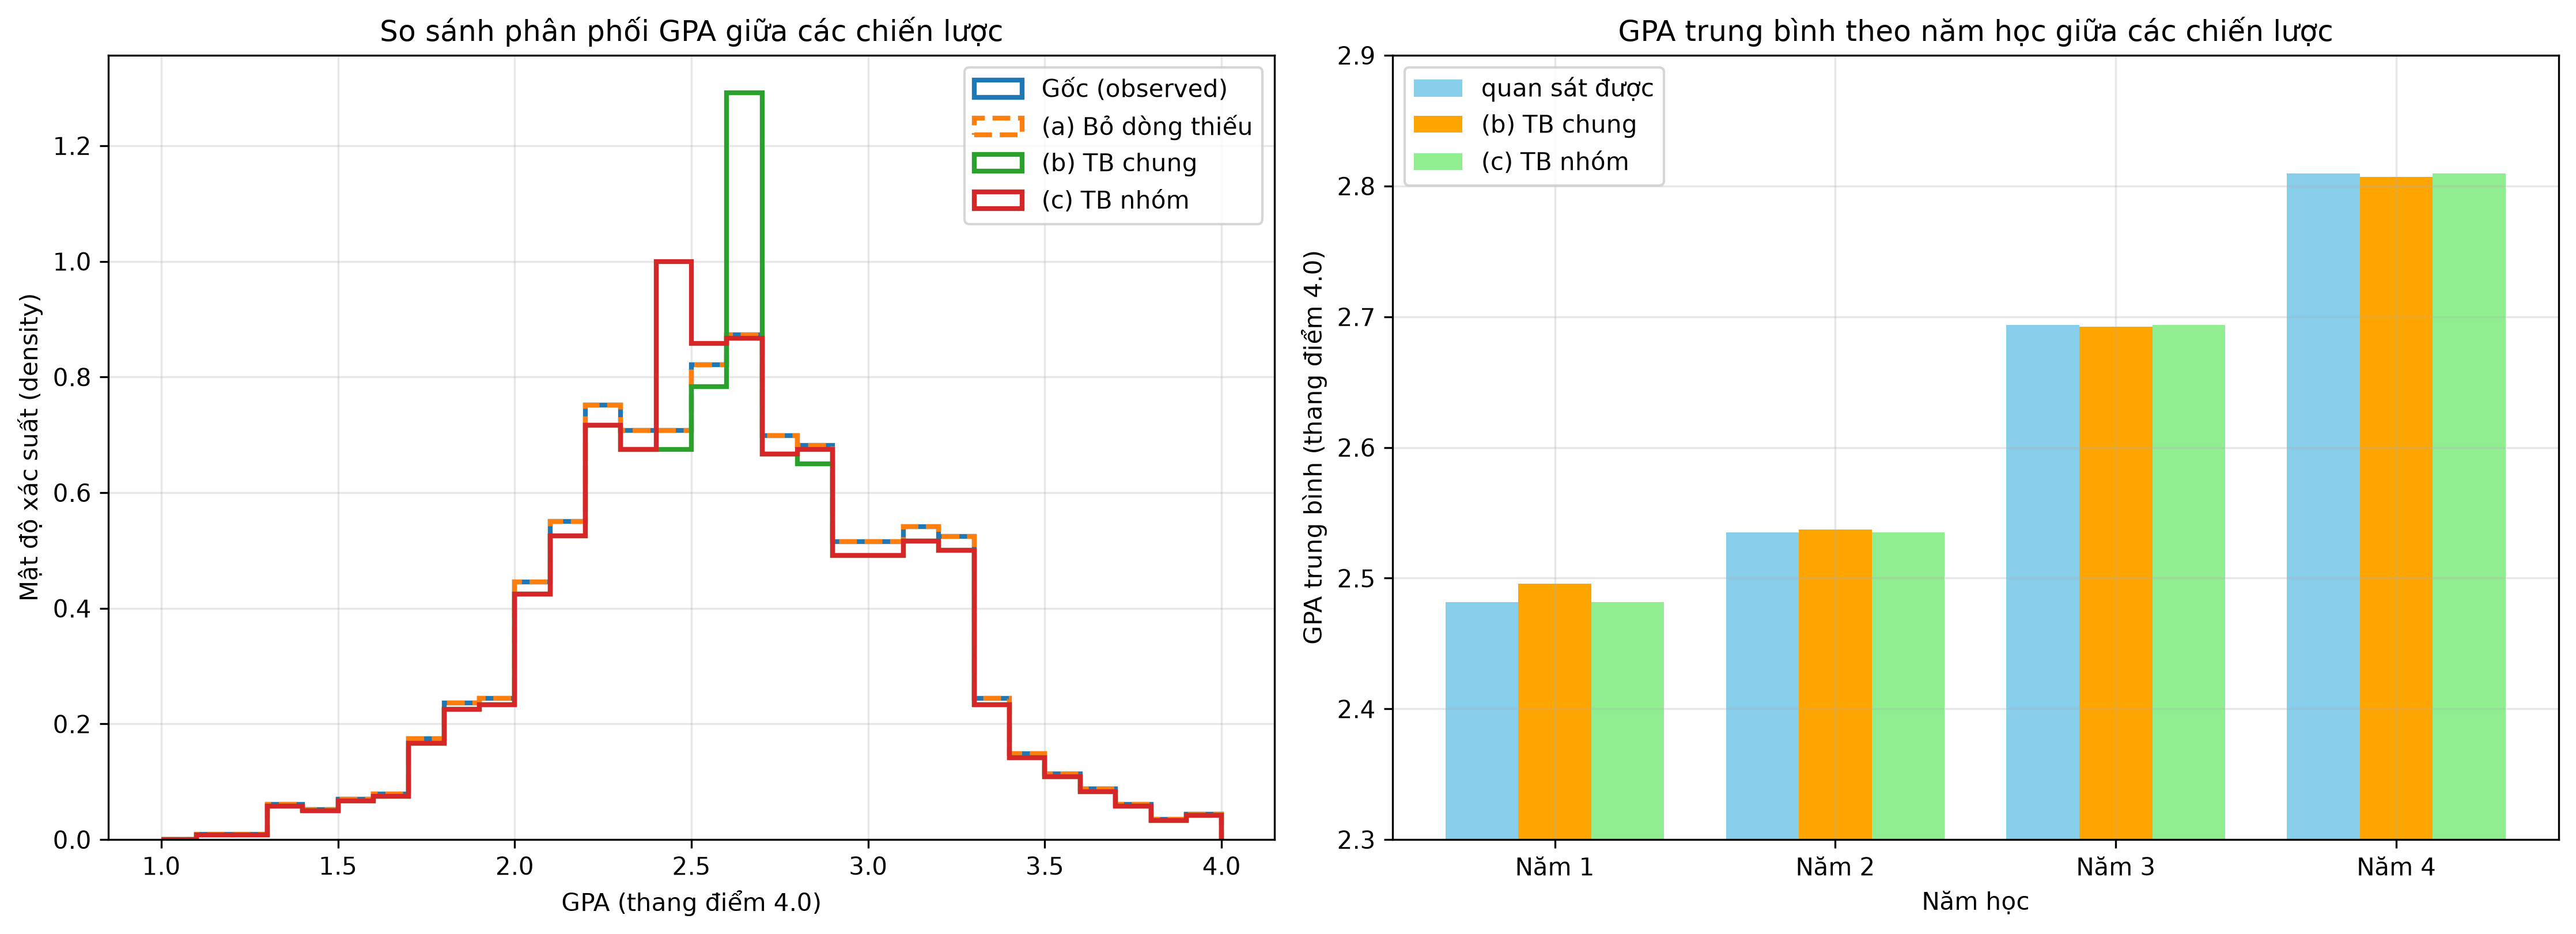

Task 4 ĐẠT.


In [16]:
# --- 4.3 Vẽ ba phân phối cùng với phân phối gốc, trên MỘT hình ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

bins = np.linspace(1.0, 4.0, 31)
ax1.hist(original.dropna(), bins=bins, histtype="step", density=True, linewidth=2, label="Gốc (observed)")
ax1.hist(A, bins=bins, histtype="step", density=True, linewidth=2, linestyle="--", label="(a) Bỏ dòng thiếu")
ax1.hist(B, bins=bins, histtype="step", density=True, linewidth=2, label="(b) TB chung")
ax1.hist(C, bins=bins, histtype="step", density=True, linewidth=2, label="(c) TB nhóm")
ax1.set_xlabel("GPA (thang điểm 4.0)")
ax1.set_ylabel("Mật độ xác suất (density)")
ax1.set_title("So sánh phân phối GPA giữa các chiến lược")
ax1.legend()

x = np.arange(len(by_year))
w = 0.26
ax2.bar(x - w, by_year["quan sát được"], width=w, label="quan sát được", color="skyblue")
ax2.bar(x, by_year["(b) TB chung"], width=w, label="(b) TB chung", color="orange")
ax2.bar(x + w, by_year["(c) TB nhóm"], width=w, label="(c) TB nhóm", color="lightgreen")
ax2.set_xticks(x)
ax2.set_xticklabels([f"Năm {yr}" for yr in by_year.index])
ax2.set_ylim(2.3, 2.9)
ax2.set_xlabel("Năm học")
ax2.set_ylabel("GPA trung bình (thang điểm 4.0)")
ax2.set_title("GPA trung bình theo năm học giữa các chiến lược")
ax2.legend()

fig.tight_layout()
fig.savefig("tuan02_so_sanh_dien_khuyet.png", dpi=300, bbox_inches="tight")
plt.show()

assert ax1.get_xlabel() and ax1.get_ylabel() and ax1.get_title()
assert ax2.get_xlabel() and ax2.get_ylabel() and ax2.get_title()
print("Task 4 ĐẠT.")


### Kết luận của bạn

![So sánh 3 chiến lược điền khuyết](tuan02_so_sanh_dien_khuyet.png)


1. **Tỉ lệ thiếu `gpa` không đều giữa các năm học. Con số cụ thể:** Năm 1 thiếu **10.80%** (39/361 sinh viên), Năm 2 thiếu **2.83%** (9/318), Năm 3 thiếu **1.40%** (4/285), Năm 4 thiếu **1.27%** (3/236).
2. **Nhóm thiếu nhiều nhất có GPA cao hay thấp so với các nhóm còn lại? Vì sao điều đó nguy hiểm?** Nhóm thiếu nhiều nhất (Năm 1) có GPA trung bình thấp nhất (2.4815 so với 2.8095 của Năm 4). Điều này nguy hiểm vì dữ liệu thiếu có tính hệ thống (MNAR/MAR), việc xử lý bất cẩn sẽ làm sai lệch nghiêm trọng phân phối điểm tổng thể.
3. **Chiến lược (a) làm gì với thành phần mẫu? Nhìn tỷ trọng sinh viên năm 1 trước/sau.** Chiến lược (a) làm giảm tỷ trọng sinh viên Năm 1 từ **0.3008** xuống **0.2812** do loại bỏ tới 39 sinh viên năm nhất, làm méo mó thành phần cơ cấu đại diện của mẫu nghiên cứu.
4. **Chiến lược (b) giữ nguyên trung bình chung 2.6148 — nghe có vẻ an toàn. Nhưng nhìn bảng theo từng năm: nó làm gì với trung bình của năm 1?** Nó kéo trung bình GPA của sinh viên Năm 1 từ 2.4815 lên **2.4959** (lệch +0.0144), tức là gán điểm cao hơn thực tế cho sinh viên năm nhất và làm sai lệch bức tranh học lực của nhóm này.
5. **Vì sao `std` giảm ở cả (b) và (c)? Điều đó ảnh hưởng thế nào nếu sau này bạn tính khoảng tin cậy?** Độ lệch chuẩn `std` giảm (từ 0.4871 xuống 0.4758 và 0.4766) do điền 55 giá trị tập trung tại tâm, làm nhân tạo hóa sự thu hẹp phương sai. Hệ quả là sai số chuẩn bị tính quá nhỏ, khiến khoảng tin cậy quá hẹp và làm tăng nguy cơ mắc sai lầm loại I khi kiểm định giả thuyết.
6. **Cách nào ít làm méo nhất, và vì sao?** **Chiến lược (c) - Điền bằng trung bình theo nhóm `nam_hoc` ít làm méo nhất**. Vì nó bảo toàn trọn vẹn điểm trung bình của từng năm học đúng bằng phần quan sát được (độ lệch bằng 0.0000 ở cả 4 năm), đồng thời giữ nguyên dung lượng mẫu 1200 và tỷ trọng đại diện của sinh viên năm nhất.
7. **Theo bạn vì sao sinh viên năm 1 thiếu GPA nhiều hơn hẳn? Nếu giả thuyết của bạn đúng thì cách xử lý đúng nhất có còn là "điền" nữa không?** Sinh viên năm nhất mới nhập học, chưa hoàn thành đủ số tín chỉ hoặc chưa kịp chốt điểm học kỳ. Nếu đúng như vậy thì họ chưa từng có GPA, do đó cách xử lý đúng nhất không phải là điền điểm giả tạo mà là tách riêng nhóm năm nhất để phân tích hoặc thêm cờ chỉ báo trạng thái điểm chưa tích lũy.


---
# Mở rộng (tự chọn) — dựng lại hai biểu đồ bằng Seaborn

Nếu còn thời gian: dựng lại biểu đồ **(1)** và **(2)** của Task 1 bằng Seaborn, rồi lập luận xem bản nào truyền đạt tốt hơn.

**Các bước**

1. `sns.histplot` cho phân phối GPA — thêm `hue` để tách theo `nam_hoc`. Đây là thứ matplotlib thuần làm được nhưng tốn khoảng mười dòng.
2. `sns.boxplot` cho GPA theo khoa.
3. Dùng `palette="colorblind"` — khoảng 8% nam giới bị mù màu đỏ-lục, và bảng màu mặc định không an toàn.
4. Vẫn phải đặt lại nhãn trục: **Seaborn đặt tên cột làm nhãn**, mà `gpa` hay `khoa` không phải là nhãn cho người đọc.

**Kết quả mong đợi.** Hai biểu đồ, lưu ở `tuan02_seaborn.png`, 300 dpi. Seaborn sẽ in một `MatplotlibDeprecationWarning` về tham số `vert` — đó là warning nội bộ của seaborn 0.13 với matplotlib 3.11, vô hại.

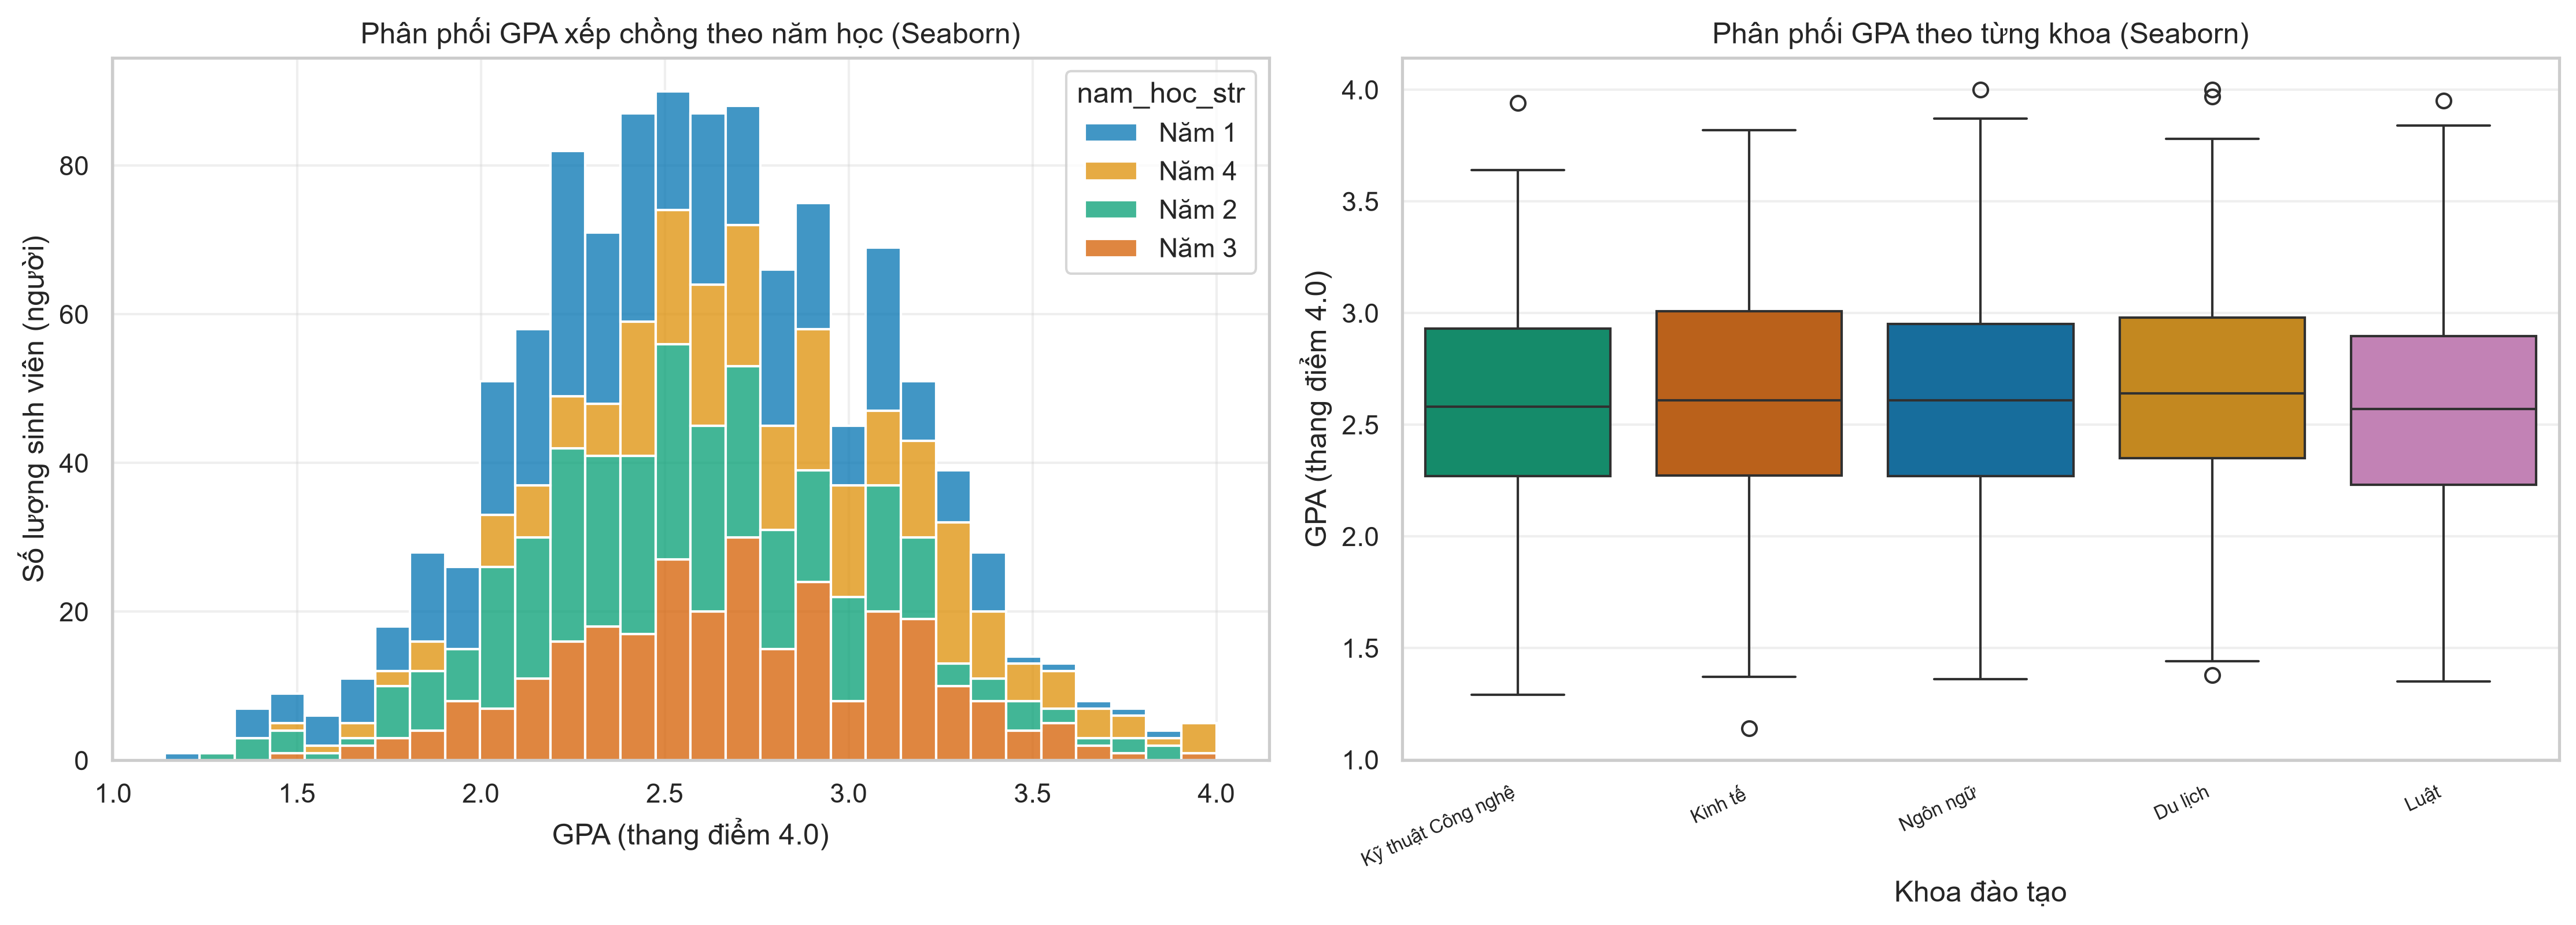

In [17]:
# --- Mở rộng (tự chọn): dựng lại biểu đồ (1) và (2) của Task 1 bằng Seaborn ---
sns.set_theme(style="whitegrid")
fig, (axa, axb) = plt.subplots(1, 2, figsize=(15, 5.5))

sv_plot = sv.dropna(subset=["gpa"]).copy()
sv_plot["nam_hoc_str"] = "Năm " + sv_plot["nam_hoc"].astype(str)

sns.histplot(data=sv_plot, x="gpa", hue="nam_hoc_str", bins=30, multiple="stack",
             palette="colorblind", ax=axa)
axa.set_xlabel("GPA (thang điểm 4.0)")
axa.set_ylabel("Số lượng sinh viên (người)")
axa.set_title("Phân phối GPA xếp chồng theo năm học (Seaborn)")

fac_order = sv["khoa"].value_counts().index.tolist()
sns.boxplot(data=sv_plot, x="khoa", y="gpa", order=fac_order, hue="khoa",
            palette="colorblind", legend=False, ax=axb)
axb.set_xlabel("Khoa đào tạo")
axb.set_ylabel("GPA (thang điểm 4.0)")
axb.set_title("Phân phối GPA theo từng khoa (Seaborn)")
plt.setp(axb.get_xticklabels(), rotation=25, ha="right", fontsize=8)

fig.tight_layout()
fig.savefig("tuan02_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()
sns.set_theme(style="white")     # trả lại mặc định để không ảnh hưởng ô khác


### Bản nào truyền đạt tốt hơn?

![Trực quan hóa Seaborn](tuan02_seaborn.png)


1. **Bản Seaborn cho bạn thêm thông tin gì mà bản matplotlib ở Task 1 không có?**
- Thể hiện được cơ cấu thành phần của các năm học bên trong từng khoảng điểm GPA nhờ kỹ thuật xếp chồng (`multiple="stack"`), cho thấy sinh viên Năm 1 tập trung chủ yếu ở dải điểm thấp còn Năm 4 chiếm ưu thế ở dải điểm cao.

2. **Có thông tin nào bản matplotlib thể hiện rõ hơn không?**
- Bản matplotlib thể hiện đường viền phân phối tổng thể toàn trường một cách trực diện, rõ ràng và không bị phân mảnh bởi nhiều màu sắc con; đồng thời việc kiểm soát nhãn số lượng tuyệt đối trên từng cột trực quan hơn.

3. **Bao nhiêu dòng code mỗi bản? Đánh đổi giữa số dòng và khả năng kiểm soát nằm ở đâu?**
- Seaborn tốn khoảng 3–5 dòng lệnh chính; Matplotlib tốn khoảng 10–15 dòng cho mỗi biểu đồ. Sự đánh đổi: Seaborn code ngắn gọn, tích hợp sẵn các biểu đồ thống kê đa chiều phức tạp; Matplotlib cho phép kiểm soát tuyệt đối từng chi tiết đồ họa, vị trí văn bản và cách bố trí các trục phụ.

4. **Nếu phải đưa một trong hai vào báo cáo gửi Ban Giám hiệu, bạn chọn bản nào, vì sao?**
- Tôi chọn **bản Seaborn**, vì Ban Giám hiệu cần cái nhìn đa chiều về chất lượng đào tạo theo từng khóa sinh viên để hoạch định chính sách kịp thời (nhận diện khóa nào đang cần trợ giúp học thuật), và bảng màu `colorblind` đảm bảo tính khả dụng tối đa cho mọi người đọc báo cáo.


---
# Danh sách kiểm tra trước khi nộp

Chạy **Kernel → Restart Kernel and Run All Cells** một lần cuối. Nếu có ô nào lỗi, notebook chưa nộp được.

**Tệp nộp**

- [ ] `Tuan02_ThucHanh_VI.ipynb` — chạy hết từ trên xuống, không ô nào lỗi
- [ ] `tuan02_6bieudo.png` — bảng 6 biểu đồ, 300 dpi (~0,9 MB)
- [ ] `banhang_sach.csv` — 900 dòng × 8 cột
- [ ] `tuan02_so_sanh_dien_khuyet.png` — hình so sánh của Task 4

**Nội dung**

- [ ] **Task 1** — đủ 6 biểu đồ; **mọi** trục có nhãn kèm đơn vị; colorbar của heatmap có nhãn; ô tự kiểm tra in `ĐẠT`
- [ ] **Task 1** — đã viết 6 câu nhận định, mỗi câu nói một điều dữ liệu cho biết
- [ ] **Task 2** — `profile()` trả về DataFrame, đúng 1 dòng/cột, chạy được trên cả hai tệp và cả trường hợp biên
- [ ] **Task 3** — cả 8 bước chạy qua `assert`; bước 3.8 báo **0/900** dòng lệch
- [ ] **Task 3** — **Nhật ký làm sạch điền đầy đủ**, mỗi dòng có lý do thật, và đã trả lời cả ba câu hỏi cuối
- [ ] **Task 3** — đã viết lập luận cho ba quyết định: ngày `31/02`, hai cột thiếu, bảy dòng ngoại lai
- [ ] **Task 4** — đã đo tỉ lệ thiếu theo `nam_hoc` **trước khi** điền; có bảng so sánh theo từng năm; có kết luận nêu rõ cách nào ít méo nhất và vì sao

**Hai câu tự hỏi trước khi bấm nộp**

1. Nếu xóa hết kết quả và gửi notebook cho bạn cùng lớp, người đó chạy lại có ra **đúng** những con số này không?
2. Trong nhật ký làm sạch, có dòng nào mà lý do chỉ là "để dữ liệu sạch hơn" không? Nếu có, dòng đó chưa hoàn thành.

> **Nhắc lại lần cuối.** Nhật ký làm sạch được chấm ngang với phần code. Một notebook chạy hoàn hảo nhưng không giải thích được vì sao lại quyết định như vậy thì không phải một bài phân tích — nó chỉ là một chuỗi thao tác.